In [1]:
import re  # 正则表达式函数

In [2]:
with open("第一章-笼中雀.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 6317
第1章 惊蛰
二月二，龙抬头。

暮色里，小镇名叫泥瓶巷的僻静地方，有位孤苦伶仃的清瘦少年，此时他正按照习俗，一手持蜡烛，一手持桃枝，照耀房梁、墙壁、木床等处，用桃枝敲敲打打，试图借此驱赶蛇蝎、蜈蚣


---

# 开发一个简单的分词器

In [3]:
def pre_tokenize(text: str):
    pattern = re.compile(
        r"""(
            --                        # 双连字符
            |[,.!?;:()"']            # 英文标点
            |[，。！？；：（）“”‘’]   # 中文标点
            |\d+\.\d+                # 小数
            |\d+                     # 整数
            |[A-Za-z]+               # 英文单词
            |[\u4e00-\u9fff]         # 单个中文字符（关键！）
            |\s+                     # 空白
        )""",
        re.VERBOSE
    )

    tokens = pattern.findall(text) # 返回字符串中所有与正则表达式匹配的子串列表
    # 去掉纯空格 token
    tokens = [t for t in tokens if not t.isspace()]
    return tokens

In [4]:
preprocessed = pre_tokenize(raw_text)
print(len(preprocessed))
print(preprocessed[:30])

6111
['第', '1', '章', '惊', '蛰', '二', '月', '二', '，', '龙', '抬', '头', '。', '暮', '色', '里', '，', '小', '镇', '名', '叫', '泥', '瓶', '巷', '的', '僻', '静', '地', '方', '，']


# 构建词汇表并映射为 ID

In [5]:
all_words = sorted(set(preprocessed)) # 排序字母 并 去重
vocab_size = len(all_words)
print(vocab_size)

vocab = {token : integer for integer, token in enumerate(all_words)} # 分配唯一整数 ID
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

1155
('1', 0)
('2', 1)
('“', 2)
('”', 3)
('。', 4)
('一', 5)
('七', 6)
('万', 7)
('丈', 8)
('三', 9)
('上', 10)
('下', 11)
('不', 12)
('与', 13)
('丑', 14)
('且', 15)
('世', 16)
('东', 17)
('丢', 18)
('两', 19)
('严', 20)
('个', 21)
('丫', 22)
('中', 23)
('串', 24)
('为', 25)
('主', 26)
('么', 27)
('义', 28)
('之', 29)
('乎', 30)
('乏', 31)
('乐', 32)
('乘', 33)
('也', 34)
('习', 35)
('乡', 36)
('书', 37)
('买', 38)
('乱', 39)
('了', 40)
('事', 41)
('二', 42)
('于', 43)
('亏', 44)
('云', 45)
('五', 46)
('井', 47)
('些', 48)
('交', 49)
('京', 50)


## 功能全部封装成一个 SimpleTokenizerV1 类

In [6]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab # 属性: 词汇表
        self.int_to_str = {i:s for s,i in vocab.items()} # 属性: 反向词汇表，用于id映射回原始文本
    def encode(self, text):
        pattern = re.compile(
            r"""(
                --                        # 双连字符
                |[,.!?;:()"']            # 英文标点
                |[，。！？；：（）“”‘’]   # 中文标点
                |\d+\.\d+                # 小数
                |\d+                     # 整数
                |[A-Za-z]+               # 英文单词
                |[\u4e00-\u9fff]         # 单个中文字符（关键！）
                |\s+                     # 空白
            )""",
            re.VERBOSE
        )
        tokens = pattern.findall(text) # 返回字符串中所有与正则表达式匹配的子串列表
        tokens = [t for t in tokens if not t.isspace()] # 去掉纯空格 token
        ids = [self.str_to_int[s] for s in tokens] # 在属性vocab里查找 key
        return ids
        
    def decode(self, ids):
        return "".join(self.int_to_str[i] for i in ids) # 只适用于中文的排版格式

tokenizer = SimpleTokenizerV1(vocab)
text = "二月二，烛照梁，桃打墙，人间蛇虫无处藏。"
ids = tokenizer.encode(text)
print(ids)
print(tokenizer.decode(ids))

[42, 574, 42, 1152, 678, 683, 609, 1152, 607, 469, 274, 1152, 53, 1077, 923, 920, 548, 279, 918, 4]
二月二，烛照梁，桃打墙，人间蛇虫无处藏。


> [!question] 这个只有基础功能的类有的一些问题:
> 1. 不能用于除开中文外的语言
> 2. 没有出现在`字典`里的token没法处理
> 3. 代码耦合性高


---

# 字节对编码

In [7]:
from importlib.metadata import version 
import tiktoken # 实现了 BPE 的一个高效的开源库
print("tiktoken版本:", version("tiktoken"))

tiktoken版本: 0.12.0


In [8]:
tokenizer = tiktoken.get_encoding("gpt2") # GPT-2 编码器，把文本编码成 token id 序列
text = "<|endoftext|>，二月二，烛照梁，桃打墙，人间蛇虫无处藏。"
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"}) # 分词器
print(integers) # 打印令牌 id
strings = tokenizer.decode(integers) # 解码器
print(strings) # 将令牌 id 转换为 文本

[50256, 171, 120, 234, 12859, 234, 17312, 230, 12859, 234, 171, 120, 234, 163, 225, 249, 163, 227, 100, 162, 95, 223, 171, 120, 234, 162, 94, 225, 33699, 241, 161, 95, 247, 171, 120, 234, 21689, 29785, 112, 164, 249, 229, 164, 247, 104, 33768, 254, 13783, 226, 164, 245, 237, 16764]
<|endoftext|>，二月二，烛照梁，桃打墙，人间蛇虫无处藏。


#### 基于词元 ID 和解码后的文本，我们可以得出两个值得注意的观察结果:
1. 标记被分配了一个相对较大的 token ID，即50256，GPT-2 的设计 BPE tokenizer 中词表大小 = 50,257，最大 token ID = 50256。
2. BPE分词器可以正确地编码和解码未知单词，因为它可以把任何未知单词拆成已知的更小单元（子词或字节）

BPE的基本原理：通过反复合并“最频繁相邻符号”，学习出一套最优的子词表示（subword vocabulary）

# 使用滑动窗口进行数据采样

- 我们训练 LLM 一次生成一个词，因此我们需要相应地准备`训练数据`，其中序列中的下一个词代表要预测的目标词：

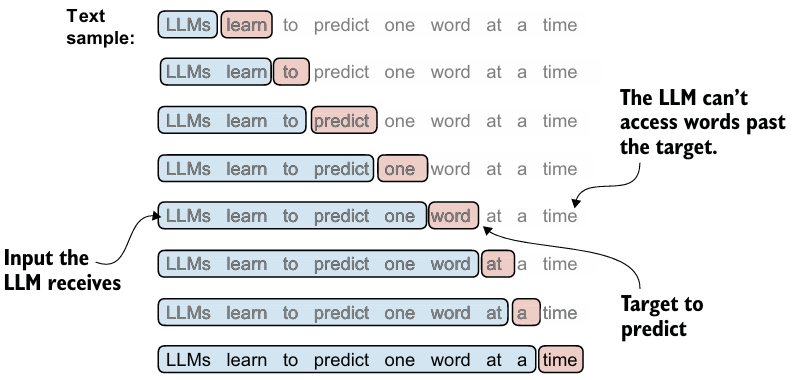

In [9]:
with open("第一章-笼中雀.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

13736


接下来，为了演示目的，我们从数据集中移除前 50 个词元，因为这样可以得到一段更有趣的文本段落，以便进行后续步骤：

In [10]:
enc_sample = enc_text[50:] # 移除前面50个次元

context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:         {y}")
print()  # ------------- 
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "----->", desired)
print()  # ------------- 
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

x: [20998, 104, 37345, 98]
y:         [104, 37345, 98, 163]

[20998] -----> 104
[20998, 104] -----> 37345
[20998, 104, 37345] -----> 98
[20998, 104, 37345, 98] -----> 163

� ----> �
叫 ----> �
叫� ----> �
叫泥 ----> �


- 目前，我们实现了一个简单的数据加载器，它遍历输入数据集，并返回偏移量为 1 的输入值和目标值。
- 为了实现高效的数据加载器，我们将输入收集到一个张量x中，其中每一行代表一个输入上下文。第二个张量y包含相应的预测目标（下一个词），它们是通过将输入向右移动一位创建的。如下图：

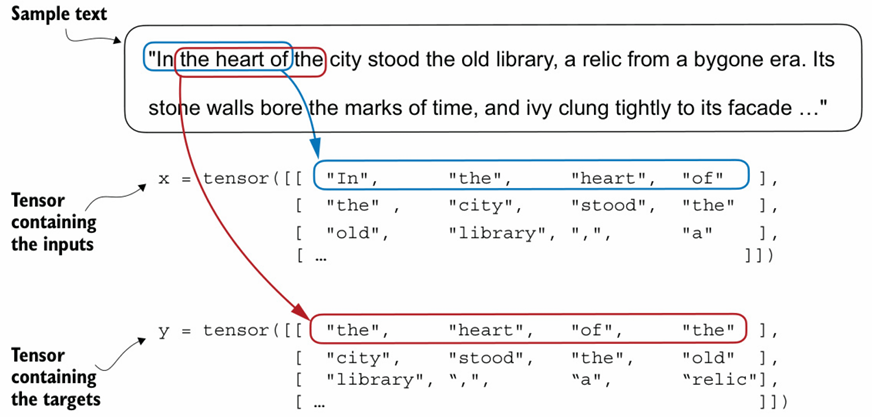

- 注意：对于高效的数据加载器实现，我们将使用PyTorch内置的Dataset和DataLoader类。

In [11]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


In [12]:
from torch.utils.data import Dataset, DataLoader
"""
类设计 - 有解耦性
Dataset      → 定义数据
DataLoader   → 怎么喂数据
"""

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [13]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [14]:
with open("第一章-笼中雀.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs_1:\n", inputs)
print("\nTargets_1:\n", targets)
print() # -----------
inputs, targets = next(data_iter)
print("Inputs_2:\n", inputs)
print("\nTargets_2:\n", targets)

Inputs_1:
 tensor([[163, 105, 105,  16]])

Targets_1:
 tensor([[  105,   105,    16, 44165]])

Inputs_2:
 tensor([[  105,   105,    16, 44165]])

Targets_2:
 tensor([[  105,    16, 44165,   254]])


- first_batch变量包含两个张量：第一个张量存储输入标记ID，第二个张量存储目标标记ID。由于max_length设置为4，因此每个张量包含四个标记ID。请注意，输入大小为4相当小，只是为了简单起见。通常，训练LLM时使用的输入大小至少为256。

In [15]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs_1:\n", inputs)
print("\nTargets_1:\n", targets)
print() # -----------
inputs, targets = next(data_iter)
print("Inputs_2:\n", inputs)
print("\nTargets_2:\n", targets)

Inputs_1:
 tensor([[  163,   105,   105,    16],
        [44165,   254, 10545,   225],
        [  232,   164,   249,   108],
        [  198, 12859,   234, 17312],
        [  230, 12859,   234,   171],
        [  120,   234, 11737,   247],
        [  162,   232,   105, 13783],
        [  112, 16764,   198,   198]])

Targets_1:
 tensor([[  105,   105,    16, 44165],
        [  254, 10545,   225,   232],
        [  164,   249,   108,   198],
        [12859,   234, 17312,   230],
        [12859,   234,   171,   120],
        [  234, 11737,   247,   162],
        [  232,   105, 13783,   112],
        [16764,   198,   198,   162]])

Inputs_2:
 tensor([[  162,   248,   106,   164],
        [  231,   110, 34932,   234],
        [  171,   120,   234, 22887],
        [  237,   165,   243,   229],
        [28938,   235, 20998,   104],
        [37345,    98,   163,   241],
        [  114, 32432,   115, 21410],
        [  161,   225,   119,   165]])

Targets_2:
 tensor([[  248,   106,   164,   231]

dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)
- raw_text = 原始文本数据             - 数据来源
- batch_size = 每次取多少样本         - 训练吞吐量
- max_length = 每个样本长度（token数）- 上下文窗口大小
- stride = 窗口移动步长               - 样本是否重叠
- shuffle = 是否打乱顺序              - 训练随机性

stride=1:
- 优点：数据利用率极高
- 缺点：样本冗余（很多重复）  
    
stride=window:
- 优点：训练更快（少样本）
- 缺点：信息损失

---

# 创建词嵌入

### 让我们通过一个实际示例来了解词元 ID 到词嵌入向量的转换是如何进行的。假设我们有以下四个输入词元，它们的 ID 分别为 2、3、5 和 1：
### 为了简单起见，假设我们只有一个包含 6 个单词的小词汇表，并且我们想要创建大小为 3 的词嵌入：

In [26]:
input_ids = torch.tensor([2, 3, 5, 1])
# 创建一个一维张量，表示“词ID序列”
# 这里可以理解为一句话被分词后，每个词对应一个整数编号
# 例如：词表中第2、3、5、1号词

vocab_size = 6 
# 词表大小（总共有多少个不同的token）
# 这里表示 token 的编号范围是 [0, 5]

output_dim = 3
# embedding 向量的维度
# 每个 token 最终会被映射成一个 3 维向量

torch.manual_seed(123)
# 设置随机种子，保证每次运行生成的随机数一致（可复现）
# 影响下面 embedding 的初始化

embedding_layer = torch.nn.Embedding(vocab_size, output_dim) # 随机生成础权重矩
print(embedding_layer.weight)
# 这将产生一个 6x3 的权重矩阵：

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [24]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [21]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


### 说白了就是在 嵌入层里面，输入词 id 以获得嵌入向量。